## **2. Preprocess and Prepare Data:**

### **b. Understanding The Data by Visualization:**

We will use the "House Sales in King County, USA" dataset from Kaggle.
<br>Kaggle dataset link:
<br>https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display
import numpy as np
import os
import datetime as dt

In [2]:
CURRENT_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(CURRENT_DIR)
GET_CSV_FILE = os.path.join(PARENT_DIR, "03.Pandas/kc_house_data _rev.csv")

df_houses = pd.read_csv(GET_CSV_FILE)

Examining the raw data can reveal valuable insights, which may help you pre-process the data, making your machine learning models perform better.

In [3]:
# View the first 10 rows in the data:

with pd.option_context('display.max_columns', None):
    display(df_houses.head(10))

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7,1180.0,0.0,1955.0,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7,2170.0,400.0,1951.0,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6,770.0,0.0,1933.0,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7,1050.0,910.0,1965.0,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8,1680.0,0.0,1987.0,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1230000.0,4,4.50,5420.0,101930.0,1.0,0.0,0.0,3.0,11,3890.0,1530.0,2001.0,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715.0,6819.0,2.0,0.0,0.0,3.0,7,1715.0,0.0,1995.0,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060.0,9711.0,1.0,0.0,0.0,3.0,7,1060.0,0.0,1963.0,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780.0,7470.0,1.0,0.0,0.0,3.0,7,1050.0,730.0,1960.0,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890.0,6560.0,2.0,0.0,0.0,3.0,7,1890.0,0.0,NaN,0,98038,47.3684,-122.031,2390,7570


### **2. Multivariate Plots:**

<br>We will talk about the Correlation Matrix Plot and Scatter Plot Matrix.

**Preparing the Data for Multivariate Plots:**
<br>Create a new Dataframe by removing non-continuous or categorized data columns because:
- Correlation matrix plots are used to show the linear relation between two variables.
- Scatter plot matrices are designed to show pairwise relationships between continuous numerical variables

In [4]:
print(df_houses.columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')


1. **Drop Non-Nontinuous Columns:**
- **Categorical:** zipcode, condition, grade, waterfront, view
- **Identifiers**: id, date
- **Binary flags**: renovated, waterfront (can be kept if meaningful)

In [5]:
non_continuous = ['id', 'date', 'zipcode', 'condition', 'grade', 'waterfront', 'view']
df_continuous = df_houses.drop(columns=non_continuous, errors='ignore')

display(df_continuous.head())

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180.0,5650.0,1.0,1180.0,0.0,1955.0,0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570.0,7242.0,2.0,2170.0,400.0,1951.0,1991,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770.0,10000.0,1.0,770.0,0.0,1933.0,0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960.0,5000.0,1.0,1050.0,910.0,1965.0,0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680.0,8080.0,1.0,1680.0,0.0,1987.0,0,47.6168,-122.045,1800,7503


In [6]:
# Optional:
# The "select_dtypes" method is a pandas method that filters columns based on their data types.
# include='number' tells pandas to keep only columns with numeric types:
# int64, float64, int32, float32, etc.
# This excludes: Strings (object), Dates (datetime64), Booleans (bool), Categorical types
# It will not remove discrete, ordinal, or Binary numbers.

df_numbers = df_houses.select_dtypes(include='number')
display(df_numbers.head())

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7,1180.0,0.0,1955.0,0,98178,47.5112,-122.257,1340,5650
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7,2170.0,400.0,1951.0,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6,770.0,0.0,1933.0,0,98028,47.7379,-122.233,2720,8062
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7,1050.0,910.0,1965.0,0,98136,47.5208,-122.393,1360,5000
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8,1680.0,0.0,1987.0,0,98074,47.6168,-122.045,1800,7503


🧠 **Are Year Columns Continuous?**

Technically, yes — years are numerical and ordered, so they can be treated as continuous. But context matters:
- **yr_built:** Often useful — older homes may correlate with price, condition, or renovation.
- **yr_renovated:** Can be misleading — many values are zero or missing (i.e., never renovated). You can convert zeros to NaN or a binary flag.
- **date:** Usually a timestamp — not useful unless you extract features like year_sold, month_sold, or season.

In [7]:
# Convert yr_renovated to a binary flag:
df_houses['was_renovated'] = df_houses['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
display(df_houses.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,was_renovated
0,7129300520,20141013T000000,221900.0,3,1.00,1180.0,5650.0,1.0,0.0,0.0,...,1180.0,0.0,1955.0,0,98178,47.5112,-122.257,1340,5650,0
1,6414100192,20141209T000000,538000.0,3,2.25,2570.0,7242.0,2.0,0.0,0.0,...,2170.0,400.0,1951.0,1991,98125,47.7210,-122.319,1690,7639,1
2,5631500400,20150225T000000,180000.0,2,1.00,770.0,10000.0,1.0,0.0,0.0,...,770.0,0.0,1933.0,0,98028,47.7379,-122.233,2720,8062,0
3,2487200875,20141209T000000,604000.0,4,3.00,1960.0,5000.0,1.0,0.0,0.0,...,1050.0,910.0,1965.0,0,98136,47.5208,-122.393,1360,5000,0
4,1954400510,20150218T000000,510000.0,3,2.00,1680.0,8080.0,1.0,0.0,0.0,...,1680.0,0.0,1987.0,0,98074,47.6168,-122.045,1800,7503,0


In [8]:
# Then drop "yr_renovated" from continuous data:
df_continuous = df_continuous.drop(columns=["yr_renovated"], errors='ignore').dropna()
display(df_continuous.head())

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement,yr_built,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180.0,5650.0,1.0,1180.0,0.0,1955.0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570.0,7242.0,2.0,2170.0,400.0,1951.0,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770.0,10000.0,1.0,770.0,0.0,1933.0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960.0,5000.0,1.0,1050.0,910.0,1965.0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680.0,8080.0,1.0,1680.0,0.0,1987.0,47.6168,-122.045,1800,7503


In [9]:
df_continuous["age"] = dt.datetime.today().year - df_continuous["yr_built"]
display(df_continuous.head())

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement,yr_built,lat,long,sqft_living15,sqft_lot15,age
0,221900.0,3,1.00,1180.0,5650.0,1.0,1180.0,0.0,1955.0,47.5112,-122.257,1340,5650,71.0
1,538000.0,3,2.25,2570.0,7242.0,2.0,2170.0,400.0,1951.0,47.7210,-122.319,1690,7639,75.0
2,180000.0,2,1.00,770.0,10000.0,1.0,770.0,0.0,1933.0,47.7379,-122.233,2720,8062,93.0
3,604000.0,4,3.00,1960.0,5000.0,1.0,1050.0,910.0,1965.0,47.5208,-122.393,1360,5000,61.0
4,510000.0,3,2.00,1680.0,8080.0,1.0,1680.0,0.0,1987.0,47.6168,-122.045,1800,7503,39.0


#### **a. Correlation Matrix Plot:**
A correlation matrix plot is a powerful visualization tool used to explore relationships between multiple variables in a dataset.

##### **Purpose of a Correlation Matrix Plot:**
- **Visualize pairwise correlations:**
  <br>It shows how strongly each variable is related to every other variable, using correlation coefficients (typically Pearson's r).
- **Detect multicollinearity:**
  <br>In regression or machine learning, it helps identify variables that are highly correlated and might cause redundancy or instability in models.
- **Feature selection:**
  <br>You can spot variables that are either too similar (redundant) or unrelated (potentially irrelevant) for predictive modeling.
- Data exploration:
  <br>It gives a quick overview of the structure and relationships within your dataset before deeper analysis.

#### **How to read the Correlation Matrix Plot:**
- Each cell in the matrix represents the correlation between two variables.
- Values range from -1 to +1:
  <br>+1: Perfect positive correlation
  <br>0: No correlation
  <br>-1: Perfect negative correlation

In [24]:
# Get the DataFrame column names:
col_names = df_continuous.columns
# Use the "corr" method to get the correlation values:
correlations = df_continuous.corr()
print(col_names)

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'sqft_above', 'sqft_basement', 'yr_built', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'age'],
      dtype='str')


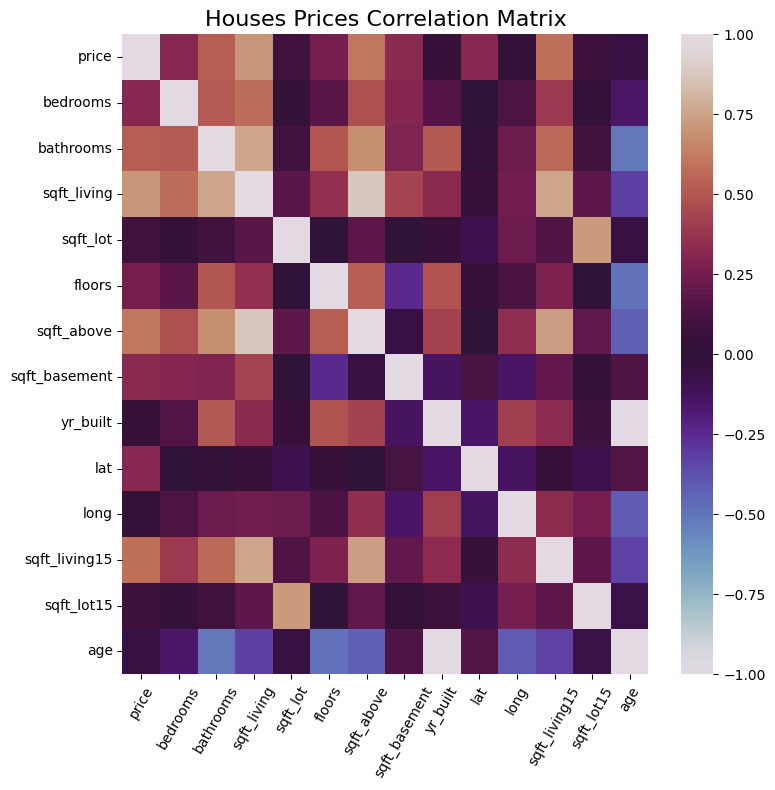

In [25]:
# Plotting the heatmap figure:

plt.figure(figsize=(8, 8))

# Create heatmap with seaborn
sns.heatmap(
    correlations,
    annot=False,                # Set to True to show correlation values
    cmap='twilight',            # Your chosen colormap
    vmin=-1, vmax=1,            # Match correlation range
    xticklabels=col_names,      # Explicitly set labels if needed
    yticklabels=col_names
)

# Rotate x-axis labels
plt.xticks(rotation=60)

plt.title("Houses Prices Correlation Matrix", fontsize=16)

# To automatically adjusts the spacing between subplots, labels, and titles to prevent overlap
# and improve readability, the "tight_layout" layout optimizer is used. 
plt.tight_layout()
plt.show()


When analyzing a correlation heatmap for machine learning, you're looking for patterns that help you understand relationships between features — which can guide feature selection, model design, and data preprocessing. Such as:

<br> 1. Highly Correlated ***Features*** (|r| > threshold, it may be between 0.9 and 0.7)
- Positive correlation (close to +1): Variables move together (Both increasing).
- Negative correlation (close to -1): One increases while the other decreases.

Highly correlated features may be redundant and can cause:
1. Multicollinearity, especially in models like linear regression or logistic regression, may lead to unstable coefficients, means that if two features are highly correlated, the model struggles to decide how much weight to assign to each.
2. Overfitting in complex models
3. Slower training and less generalization

What to do:
- Drop one of the correlated features.
  <br>Or
- Use regularization (like Ridge or Lasso) and drop one of the correlated features.
  <br>Or
- Apply PCA or other dimensionality reduction, if you want to reduce dimensionality and preserve variance.
  <br>Or
- Use regularization or PCA to avoid overfitting and improve robustness.
  <br>Or
- Use tree-based models (like Random Forests), which are less sensitive to multicollinearity. There is no need to drop features — these models handle multicollinearity well.

But correlation with the Output (Target):
- If a feature is strongly correlated with the target, it likely carries predictive power.

In [46]:
# Remove all highly correlated features:
# def remove_highly_correlated_features(df, threshold=0.9):
#     # Compute correlation matrix
#     corr_matrix = df.corr().abs()

#     # Select the upper triangle of the correlation matrix, using the "triu" function with
#     # ones matrix with the same shape as the DataFrane
#     upper = corr_matrix.where(
#         np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
#     )

#     # Find features with correlation greater than threshold
#     to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

#     # Drop features
#     reduced_df = df.drop(columns=to_drop)

#     return reduced_df, to_drop

# reduced_df, dropped = remove_highly_correlated_features(df_continuous, threshold=0.75)

# display(reduced_df)

In [45]:
# Remove specific highly correlated features:
def remove_highly_correlated_features(df, target, threshold=0.9, target_corr_threshold=0.5):
    """
    Removes highly correlated features but keeps those strongly correlated with the target.
    If two target-correlated features are also highly correlated with each other, 
    keeps only the one more correlated with the target.

    Parameters:
    df (pd.DataFrame): Input dataframe
    target (str): Name of the target column
    threshold (float): Correlation threshold for dropping features
    target_corr_threshold (float): Minimum correlation with target to force-keep a feature

    Returns:
    reduced_df (pd.DataFrame): Dataframe with reduced features
    dropped_features (list): List of dropped features
    summary (pd.DataFrame): Table showing kept/dropped status and target correlation
    """

    # Compute correlation matrix
    corr_matrix = df.corr().abs()

    # Correlation of features with target
    target_corr = corr_matrix[target]

    # Select the upper triangle of the correlation matrix
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = []
    for column in upper.columns:
        high_corr_features = upper.index[upper[column] > threshold].tolist()
        for feature in high_corr_features:
            # If both are strongly correlated with target and both are also highly correlated
            # with each other, retain only the one with the higher correlation to the target.
            if (target_corr[column] >= target_corr_threshold and 
                target_corr[feature] >= target_corr_threshold):
                if target_corr[column] < target_corr[feature]:
                    to_drop.append(column)
                else:
                    to_drop.append(feature)
            else:
                # If only one is strongly correlated with target, keep it
                if target_corr[column] >= target_corr_threshold:
                    to_drop.append(feature)
                elif target_corr[feature] >= target_corr_threshold:
                    to_drop.append(column)
                else:
                    # Both features are highly correlated with each other, and
                    # neither strongly correlated with target → drop weaker one
                    if target_corr[column] < target_corr[feature]:
                        to_drop.append(column)
                    else:
                        to_drop.append(feature)

    # Deduplicate
    to_drop = list(set(to_drop))

    # Drop features
    reduced_df = df.drop(columns=to_drop)

    # Build summary table
    summary = pd.DataFrame({
        "Feature": target_corr.index,
        "TargetCorrelation": target_corr.values,
        "Status": ["Dropped" if f in to_drop else "Kept" for f in target_corr.index]
    })

    return reduced_df, to_drop, summary

reduced_df, dropped, summary = remove_highly_correlated_features(
    df_continuous, "price", threshold=0.85, target_corr_threshold=0.6
)

display("Dropped features:", dropped)
display(summary.sort_values("TargetCorrelation", ascending=False))

'Dropped features:'

['sqft_above', 'yr_built']

,Feature,TargetCorrelation,Status
0,price,1.000000,Kept
3,sqft_living,0.701962,Kept
6,sqft_above,0.605702,Dropped
11,sqft_living15,0.585146,Kept
2,bathrooms,0.525406,Kept
7,sqft_basement,0.323059,Kept
1,bedrooms,0.308009,Kept
9,lat,0.307122,Kept
5,floors,0.257599,Kept
4,sqft_lot,0.089903,Kept


In the above case, the dropped features are sqft_above and yr_built. However, sqft_above may still be retained during feature engineering, since it can contribute to derived variables related to the overall house area.

#### **b. Scatter Plot Matrix:**
A scatter plot matrix (also known as a pair plot) is a powerful visualization tool used to explore relationships between multiple numerical variables in a dataset.

What Is a Scatter Plot Matrix?
- Structure: A grid of plots where each cell shows a scatter plot of two variables.
- Diagonal: Shows histograms or kernel density plots of individual variables.
- Purpose: Helps identify correlations, clusters, outliers, and patterns across multiple variables.

In [20]:
# Bin price into categories
reduced_df['price_bin'] = pd.qcut(reduced_df['price'], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

How to bin "price" column into categories:
- **pd.qcut** divides the price column into quantile-based bins (here, quartiles).
- **q=4** means the data is split into 4 equal-sized groups based on distribution.
- Each bin is labeled with "Low", "Mid-Low", "Mid-High", "High".
- Result: every row gets assigned to one of these categories depending on its price.

In [21]:
reduced_df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_basement,lat,long,sqft_living15,sqft_lot15,age,price_bin
0,221900.0,3,1.00,1180.0,5650.0,1.0,0.0,47.5112,-122.257,1340,5650,71.0,Low
1,538000.0,3,2.25,2570.0,7242.0,2.0,400.0,47.7210,-122.319,1690,7639,75.0,Mid-High
2,180000.0,2,1.00,770.0,10000.0,1.0,0.0,47.7379,-122.233,2720,8062,93.0,Low
3,604000.0,4,3.00,1960.0,5000.0,1.0,910.0,47.5208,-122.393,1360,5000,61.0,Mid-High
4,510000.0,3,2.00,1680.0,8080.0,1.0,0.0,47.6168,-122.045,1800,7503,39.0,Mid-High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530.0,1131.0,3.0,0.0,47.6993,-122.346,1530,1509,17.0,Mid-Low
21609,400000.0,4,2.50,2310.0,5813.0,2.0,0.0,47.5107,-122.362,1830,7200,12.0,Mid-Low
21610,402101.0,2,0.75,1020.0,1350.0,2.0,0.0,47.5944,-122.299,1020,2007,17.0,Mid-Low
21611,400000.0,3,2.50,1600.0,2388.0,2.0,0.0,47.5345,-122.069,1410,1287,22.0,Mid-Low


In [22]:
# Optional: sample for speed
df_sampled = reduced_df.sample(n=1000, random_state=42)

Sample for speed:
- Randomly selects 1000 rows from the dataset.
- random_state=42 ensures reproducibility (same sample every time).
- This is useful because pairplots can be slow on large datasets.

"sns.pairplot" creates a scatter plot matrix:
- Each variable is plotted against every other variable.
- Diagonal plots show distributions (diag_kind='kde' → kernel density estimate).
- hue='price_bin' colors points by their price category, so you can visually compare how different price ranges distribute across features.
- This helps spot correlations, clusters, or separations between features and price bins.

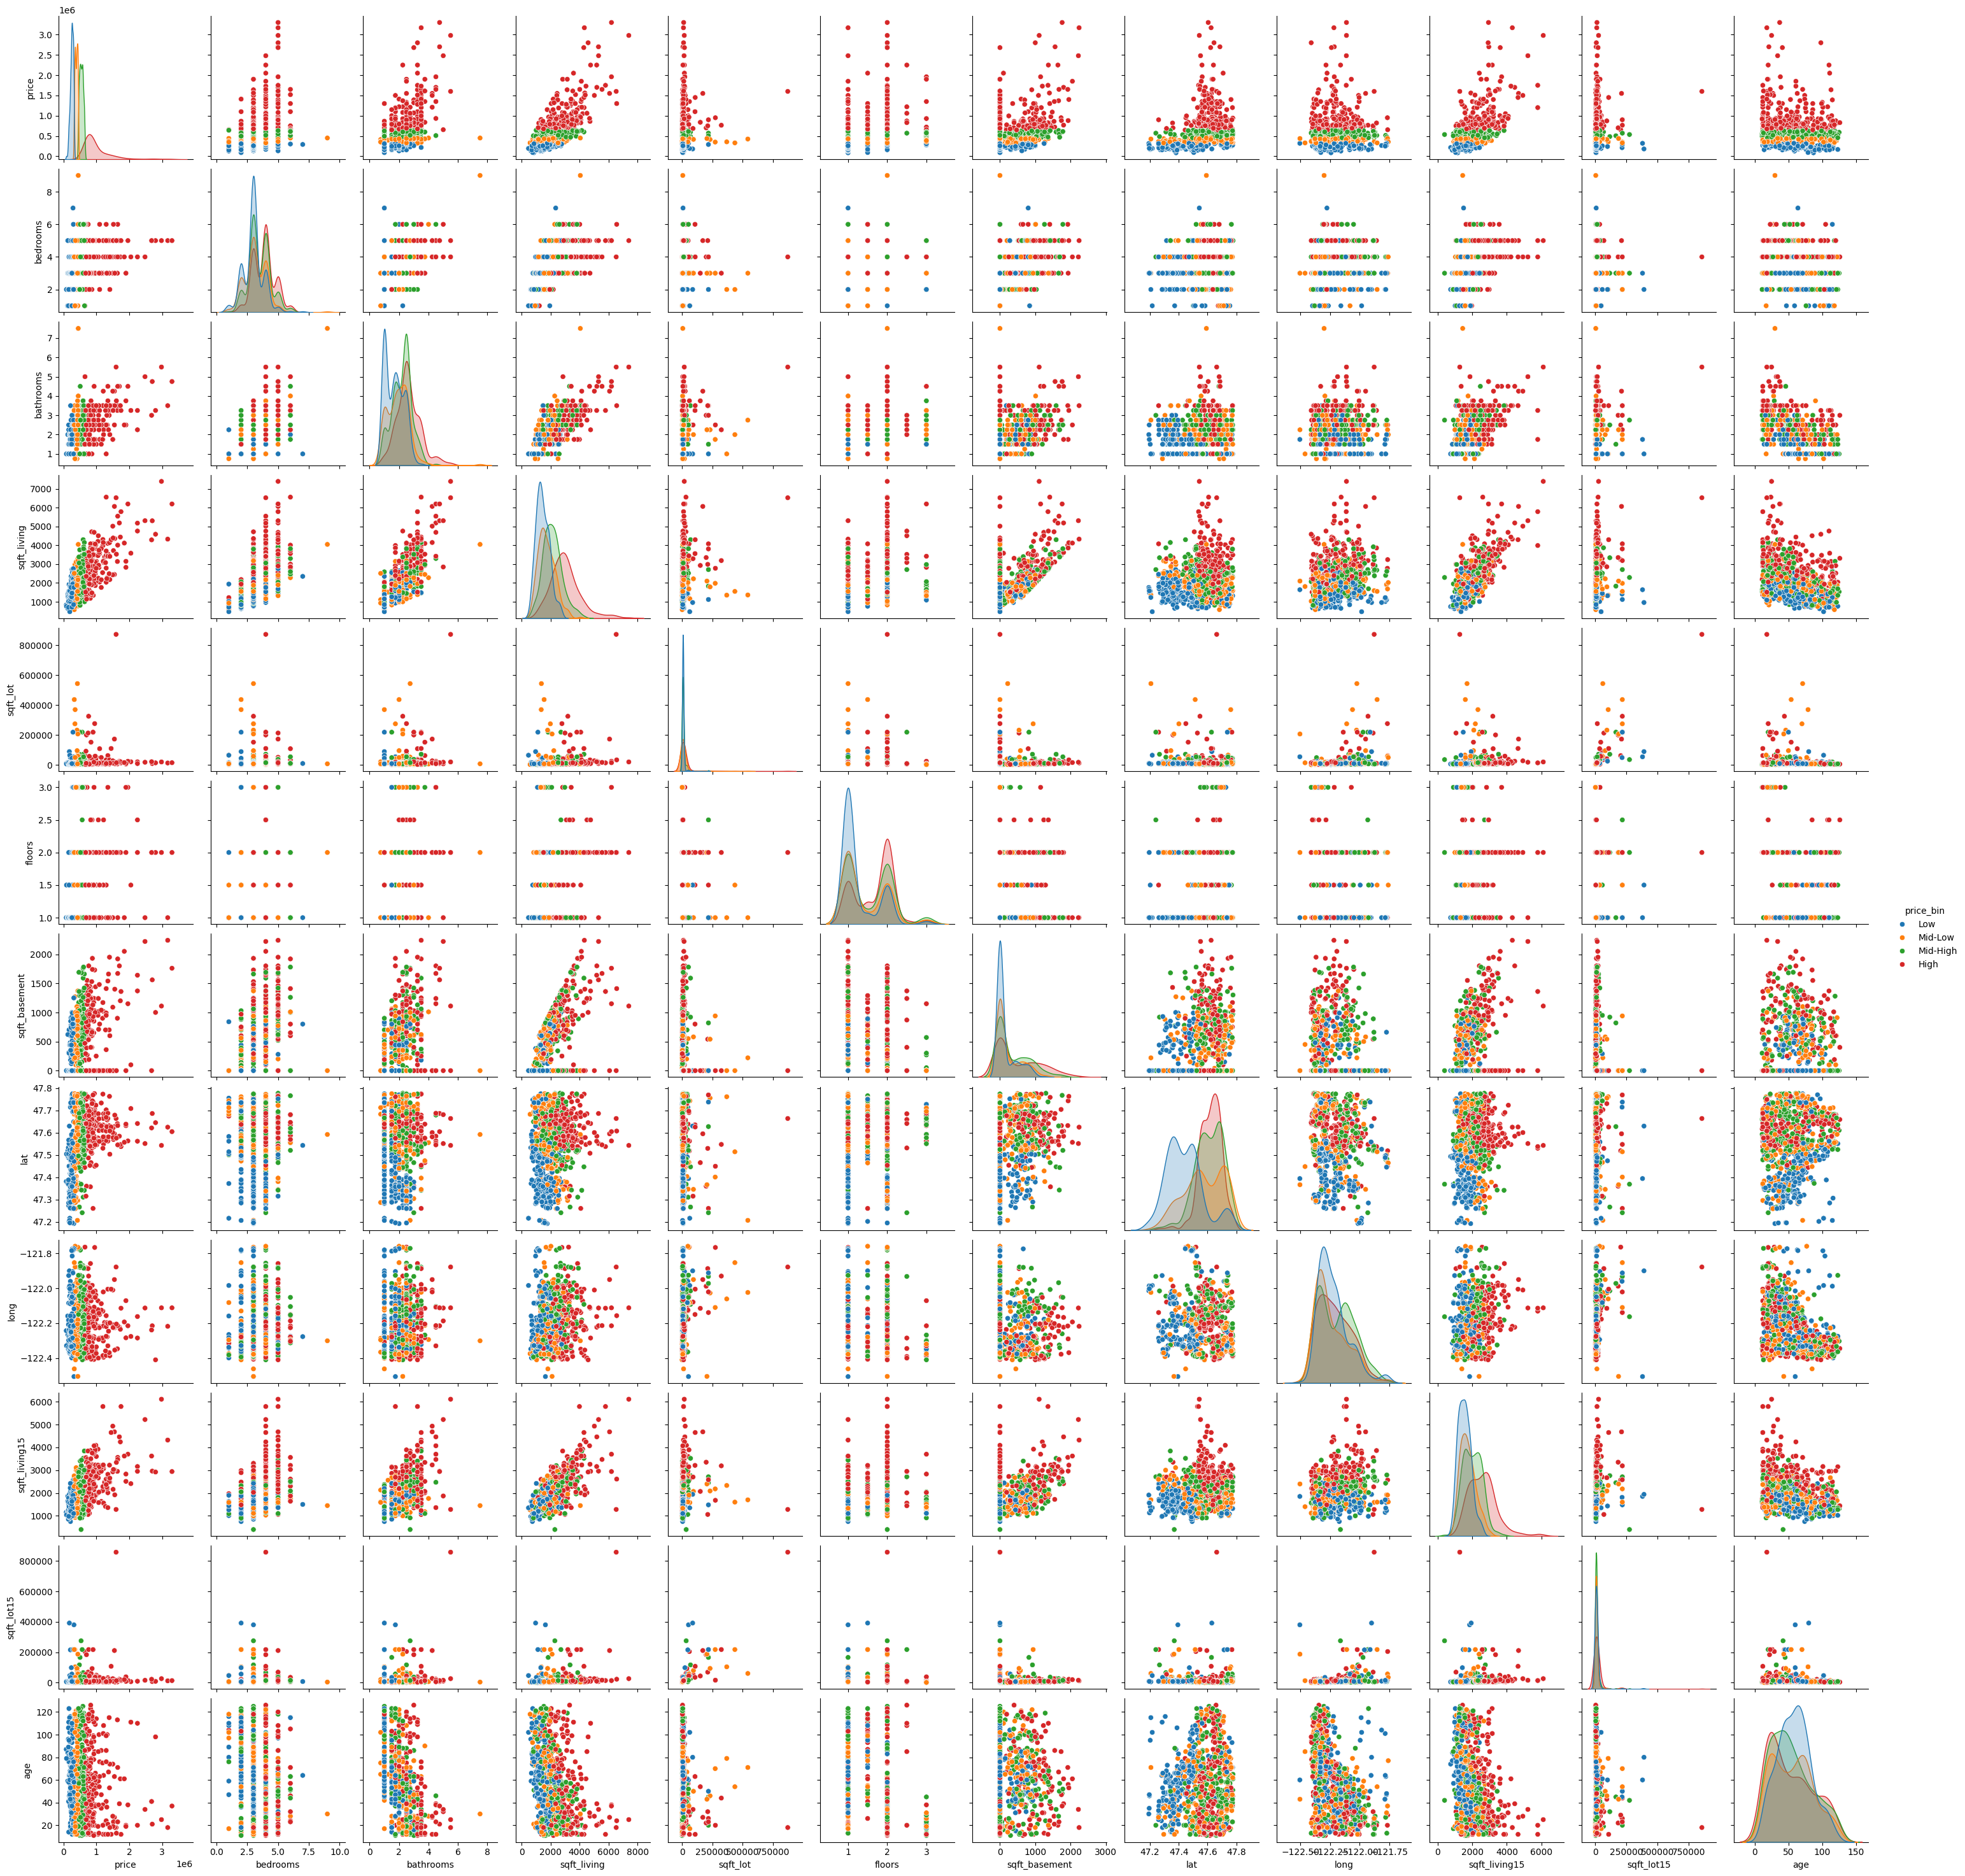

In [23]:
# Create scatter plot matrix
sns.pairplot(df_sampled, hue='price_bin', diag_kind='kde')
plt.show()

What we can extract from each part of the visualization:

📐 Diagonal — KDE Plots (per feature)
Each diagonal shows the distribution of a single feature, split by price bin.
What to look for:
- Separated peaks → the feature strongly distinguishes price tiers (good predictor)

Separated peaks mean the four bins (Low, Mid-Low, Mid-High, High) each have their density concentrated at a different part of the x-axis. A model can see the value of the feature and immediately know which price tier it likely belongs to. Think of it like this: if "square footage" shows separated peaks, small homes concentrate in the Low bin and large homes in the High bin — the feature is doing real work.
<br>Even if the "Low" peak is at $10$ and the "High" peak is at $100$ with very little overlap, that feature is a gold mine. A simple decision tree model could easily split the data based on this feature alone.

  <img src="images/separated_kde_peaks.svg" width="600" height="700">


- Overlapping curves → the feature has weak discriminatory power
  
Overlapping curves mean that knowing a feature's value tells you almost nothing about which price bin a listing belongs to. If "number of bathrooms" shows four nearly identical humps all centered at 3 bathrooms, cheap and expensive homes alike have 3 bathrooms — the feature is not useful for price prediction. You'd consider dropping it or having features engineering create a better version for them.

  <img src="images/overlapping_kde_curves.svg" width="600" height="700">

- Skewness → may need log transformation before modeling

🔵 Off-Diagonal — Scatter Plots (feature pairs)
Each cell shows two features plotted against each other, colored by price bin.


**🎯 Key ML Insights You Can Extract**
1. Feature Relevance: Features where "High" and "Low" bins form distinct, non-overlapping clusters are your strongest predictors of price.

2. Multicollinearity: If two features show a tight linear relationship, include only one in linear models (e.g., regression) to avoid redundancy.

3.  Non-linear Relationships: Curved or fan-shaped scatter patterns suggest tree-based models (XGBoost, Random Forest) may outperform linear ones.

4.  Class Separability: Well-separated color clusters → price prediction is feasible. Heavy overlap → you may need feature engineering or more data.

5.   Outliers: Isolated points far from their bin's cluster may be data quality issues or genuinely unique listings.


✅ Actionable Next Steps Based on What You See:
<br>Separated KDE peaks       → Prioritize that feature in your model
<br>Tight linear scatter      → Check correlation matrix, drop redundant features
<br>Overlapping all bins      → Feature may not help; consider dropping
<br>Curved scatter pattern    → Add polynomial features or use non-linear model
<br>One bin always isolated   → Easier to predict extremes (Low/High) than middle tiers

The most valuable cells to study closely are the ones involving your strongest candidate features (e.g., square footage, location score, age) paired with each other — that's where pricing logic lives.

**⚖️ Practical recommendation When Splitting the Target**

If your goal is exploration and balanced visuals → use qcut.

If your goal is business-friendly categories → use cut with domain thresholds.

If your goal is pattern discovery → use clustering.

If your goal is feature-driven insights → use tree-based binning.

👉 Most people start with qcut or cut because the categories are easier to interpret visually.
<br>👉Clustering and tree-based splits are more advanced and useful when you suspect hidden structure in the data.